# ChatGPT code

In [1]:
INF = float("inf")

graph = [
    [0,   2,   6,   INF],
    [2,   0,   3,   1],
    [6,   3,   0,   2],
    [INF, 1,   2,   0]
]

In [2]:
import heapq


def dijkstra(graph, start, target):
    # distance[node]：start 到 node 的当前最短距离
    distance = {node: float("inf") for node in graph}
    distance[start] = 0

    # previous[node]：最短路径中 node 的前一个节点
    previous = {node: None for node in graph}

    # 优先队列元素格式：(当前距离, 节点)
    priority_queue = [(0, start)]

    while priority_queue:
        current_dist, current_node = heapq.heappop(priority_queue)

        # 队列中的旧记录直接跳过
        if current_dist > distance[current_node]:
            continue

        # 已到达目标，提前结束
        if current_node == target:
            break

        # 遍历相邻节点
        for neighbor, weight in graph[current_node]:
            new_dist = current_dist + weight

            # 松弛操作：发现更短路径就更新
            if new_dist < distance[neighbor]:
                distance[neighbor] = new_dist
                previous[neighbor] = current_node
                heapq.heappush(priority_queue, (new_dist, neighbor))

    # 回溯最短路径
    path = []
    node = target

    while node is not None:
        path.append(node)
        node = previous[node]

    path.reverse()

    # 若目标不可达
    if distance[target] == float("inf"):
        return None, float("inf")

    return path, distance[target]


graph = {
    "A": [("B", 2), ("C", 6)],
    "B": [("A", 2), ("C", 3), ("D", 1)],
    "C": [("A", 6), ("B", 3), ("D", 2)],
    "D": [("B", 1), ("C", 2)]
}

path, shortest_time = dijkstra(graph, "A", "D")

print("最短路径：", " -> ".join(path))
print("最短运输时间：", shortest_time)

最短路径： A -> B -> D
最短运输时间： 3


In [3]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        root_x = self.find(x)
        root_y = self.find(y)

        # 已属于同一集合，加入该边会形成环
        if root_x == root_y:
            return False

        # 按秩合并，提高效率
        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y
        elif self.rank[root_x] > self.rank[root_y]:
            self.parent[root_y] = root_x
        else:
            self.parent[root_y] = root_x
            self.rank[root_x] += 1

        return True


def kruskal(n, edges):
    """
    n: 节点数，节点编号为 0 到 n-1
    edges: [(起点, 终点, 权重), ...]
    """
    edges.sort(key=lambda x: x[2])

    uf = UnionFind(n)
    mst_edges = []
    total_cost = 0

    for u, v, weight in edges:
        if uf.union(u, v):
            mst_edges.append((u, v, weight))
            total_cost += weight

        # 最小生成树有 n-1 条边
        if len(mst_edges) == n - 1:
            break

    # 检查是否所有节点均连通
    if len(mst_edges) != n - 1:
        return None, None

    return mst_edges, total_cost


edges = [
    (0, 1, 2),
    (0, 2, 6),
    (1, 2, 3),
    (1, 3, 1),
    (2, 3, 2),
    (2, 4, 5),
    (3, 4, 4)
]

mst_edges, total_cost = kruskal(5, edges)

print("选取的道路：")
for u, v, cost in mst_edges:
    print(f"{u} - {v}，建设成本：{cost}")

print("最小总建设成本：", total_cost)

选取的道路：
1 - 3，建设成本：1
0 - 1，建设成本：2
2 - 3，建设成本：2
3 - 4，建设成本：4
最小总建设成本： 9


In [4]:
import networkx as nx

G = nx.DiGraph()

# add_edge(起点, 终点, capacity=最大容量)
G.add_edge("S", "A", capacity=10)
G.add_edge("S", "B", capacity=8)
G.add_edge("A", "B", capacity=5)
G.add_edge("A", "T", capacity=7)
G.add_edge("B", "T", capacity=10)

max_flow_value, flow_dict = nx.maximum_flow(G, "S", "T")

print("最大运输量：", max_flow_value)
print("\n各线路实际运输量：")

for u in flow_dict:
    for v, flow in flow_dict[u].items():
        if flow > 0:
            print(f"{u} -> {v}: {flow}")

最大运输量： 17

各线路实际运输量：
S -> A: 10
S -> B: 7
A -> B: 3
A -> T: 7
B -> T: 10


In [5]:
from functools import lru_cache


def tsp(distance_matrix):
    """
    distance_matrix[i][j] 表示从节点 i 到节点 j 的距离
    默认从 0 号节点出发，最终回到 0 号节点
    """
    n = len(distance_matrix)

    @lru_cache(None)
    def dp(current, visited_mask):
        # 所有节点均访问完成，返回起点
        if visited_mask == (1 << n) - 1:
            return distance_matrix[current][0], [0]

        min_cost = float("inf")
        best_path = None

        for next_node in range(n):
            # 如果 next_node 尚未访问
            if not (visited_mask & (1 << next_node)):
                next_cost, next_path = dp(
                    next_node,
                    visited_mask | (1 << next_node)
                )

                total_cost = distance_matrix[current][next_node] + next_cost

                if total_cost < min_cost:
                    min_cost = total_cost
                    best_path = [next_node] + next_path

        return min_cost, best_path

    cost, path = dp(0, 1)
    return cost, [0] + path


distance_matrix = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

min_cost, best_route = tsp(distance_matrix)

print("最短巡回路径：", " -> ".join(map(str, best_route)))
print("最短总距离：", min_cost)

最短巡回路径： 0 -> 1 -> 3 -> 2 -> 0
最短总距离： 80


In [7]:
def count_connected_components(graph):
    visited = set()
    components = []

    def dfs(node, component):
        visited.add(node)
        component.append(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                dfs(neighbor, component)

    for node in graph:
        if node not in visited:
            component = []
            dfs(node, component)
            components.append(component)

    return components


graph = {
    "A": ["B", "C"],
    "B": ["A", "C"],
    "C": ["A", "B"],
    "D": ["E"],
    "E": ["D"],
    "F": []
}

components = count_connected_components(graph)

print("连通分量数量：", len(components))

for i, component in enumerate(components, start=1):
    print(f"第 {i} 个连通分量：{component}")

连通分量数量： 3
第 1 个连通分量：['A', 'B', 'C']
第 2 个连通分量：['D', 'E']
第 3 个连通分量：['F']


In [9]:
import networkx as nx

G = nx.Graph()

G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("D", "F"),
    ("E", "F")
])

# 割点
articulation_points = list(nx.articulation_points(G))

# 桥
bridges = list(nx.bridges(G))

# 介数中心性
betweenness = nx.betweenness_centrality(G)

print("关键节点（割点）：", articulation_points)
print("关键边（桥）：", bridges)

print("\n节点介数中心性：")
for node, value in sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{node}: {value:.3f}")

关键节点（割点）： ['D', 'C']
关键边（桥）： [('C', 'D')]

节点介数中心性：
C: 0.600
D: 0.600
A: 0.000
B: 0.000
E: 0.000
F: 0.000


In [10]:
import networkx as nx

G = nx.DiGraph()

G.add_edges_from([
    ("收集数据", "清洗数据"),
    ("清洗数据", "建立模型"),
    ("建立模型", "撰写报告"),
    ("建立模型", "制作展示材料")
])

order = list(nx.topological_sort(G))

print("一种可行任务顺序：")
for i, task in enumerate(order, start=1):
    print(f"{i}. {task}")

一种可行任务顺序：
1. 收集数据
2. 清洗数据
3. 建立模型
4. 撰写报告
5. 制作展示材料


最短路径： ['A', 'B', 'D']
最短距离： 3


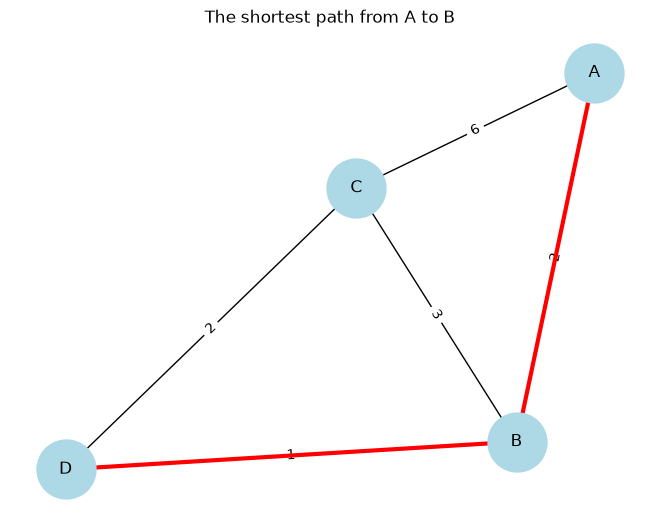

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# 创建无向带权图
G = nx.Graph()

edges = [
    ("A", "B", 2),
    ("A", "C", 6),
    ("B", "C", 3),
    ("B", "D", 1),
    ("C", "D", 2)
]

for u, v, weight in edges:
    G.add_edge(u, v, weight=weight)

# 最短路径
path = nx.shortest_path(G, source="A", target="D", weight="weight")
length = nx.shortest_path_length(G, source="A", target="D", weight="weight")

print("最短路径：", path)
print("最短距离：", length)

# 绘图
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1800,
    font_size=12
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10
)

# 用红色高亮最短路径
path_edges = list(zip(path[:-1], path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=3
)

plt.title("The shortest path from A to B")
plt.show()

# Gemini Code

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. 创建一个无向图对象
G = nx.Graph()

# 2. 添加边和对应的权重 (节点u, 节点v, 权重w)
# 数据完全对应上面图片中的图
edges = [
    (0, 1, 4),
    (0, 2, 8),
    (1, 2, 3),
    (1, 4, 6),
    (2, 3, 2),
    (3, 4, 10)
]
G.add_weighted_edges_from(edges)

# 3. 设定起点和终点
source_node = 0
target_node = 3

# 4. 调用 Dijkstra 算法求解最短路径和最短距离
# 求两点之间的最短路径
shortest_path = nx.dijkstra_path(G, source=source_node, target=target_node, weight='weight')
# 求两点之间的最短距离
shortest_distance = nx.dijkstra_path_length(G, source=source_node, target=target_node, weight='weight')

print(f"从节点 {source_node} 到节点 {target_node} 的最短路径是: {shortest_path}")
print(f"对应的最短总距离(代价值)为: {shortest_distance}")

# --- 进阶：一次性求出起点到所有节点的最短距离 ---
all_lengths = nx.single_source_dijkstra_path_length(G, source_node, weight='weight')
print(f"\n节点 {source_node} 到其他所有节点的最短距离字典: \n{all_lengths}")

从节点 0 到节点 3 的最短路径是: [0, 1, 2, 3]
对应的最短总距离(代价值)为: 9

节点 0 到其他所有节点的最短距离字典: 
{0: 0, 1: 4, 2: 7, 3: 9, 4: 10}


In [14]:
from collections import deque

def bfs(graph, start, goal):
    # graph 是一个字典，例如 {'A': ['B', 'C'], 'B': ['A', 'D']...}
    queue = deque([start])
    visited = {start}
    # 记录每个节点是从哪个节点走过来的，用于最后还原路径
    came_from = {start: None}

    while queue:
        current = queue.popleft() # 先进先出

        if current == goal:
            break

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                came_from[neighbor] = current

    # 回溯路径
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = came_from.get(curr)
    
    return path[::-1] # 反转，得到从 start 到 goal 的路径

In [15]:
import heapq

def dijkstra(graph, start, goal):
    # graph 格式: {'A': {'B': 4, 'C': 2}, 'B': {'A': 4, 'D': 3}...}
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    
    # 优先队列存放元组 (当前到该点的距离, 节点名称)
    priority_queue = [(0, start)]
    came_from = {start: None}
    
    while priority_queue:
        current_dist, current_node = heapq.heappop(priority_queue)
        
        # 如果抵达目标，可以提前终止（如果是单源最短路径则不终止）
        if current_node == goal:
            break
            
        # 如果弹出的节点距离大于已记录的距离，说明是历史遗留的旧数据，直接丢弃
        if current_dist > distances[current_node]:
            continue
            
        for neighbor, weight in graph[current_node].items():
            distance = current_dist + weight # 核心推导：d(u) + w(u, v)
            
            # 松弛操作：如果找到了更短的路径
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                came_from[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))
                
    # 回溯路径
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = came_from.get(curr)
        
    return path[::-1], distances[goal]

In [16]:
import heapq
import math

def heuristic(a, b):
    # 使用欧几里得距离作为启发函数 h(n)
    # a, b 都是坐标元组 (x, y)
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def a_star(graph, start, goal):
    # graph 格式: {(0,0): {(0,1): 1, (1,0): 1}, ...}
    # g_score 对应 g(n)
    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0
    
    # 优先队列存放元组 (f(n), 节点坐标)
    priority_queue = [(heuristic(start, goal), start)]
    came_from = {start: None}
    
    while priority_queue:
        current_f, current_node = heapq.heappop(priority_queue)
        
        if current_node == goal:
            break
            
        for neighbor, weight in graph[current_node].items():
            # 这里的 weight 可能是网格间移动的代价
            tentative_g_score = g_score[current_node] + weight
            
            # 只有找到了更小的 g(n)，我们才更新
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current_node
                g_score[neighbor] = tentative_g_score
                
                # 计算 f(n) = g(n) + h(n)
                f_score = tentative_g_score + heuristic(neighbor, goal)
                heapq.heappush(priority_queue, (f_score, neighbor))
                
    # 回溯路径
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = came_from.get(curr)
        
    return path[::-1]